# **ELT574 - Aprendizado de Máquinas**
**Curso de Especialização em Inteligência Artificial e Computacional**



## Semana 2 - Redes Neurais Artificiais

### Aula 04 - Redes perceptron multicamadas (regressão)
##### Regressor com Keras

In [ ]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.5.2
!pip install scikeras

Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
  Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [ ]:
from tensorflow import keras
from scikeras.wrappers import KerasRegressor

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV # implementa a k-fold cross-validation
from sklearn.model_selection import GridSearchCV # implementa a k-fold cross-validation com busca exaustiva
import pandas as pd
import numpy as np

Vamos fazer a estimação do preço das casas das vizinhanças da Califórnia. Este banco de dados já está limpo e sem as variáveis categóricas.

In [ ]:
# baixando do github da disciplina
!wget https://raw.githubusercontent.com/nias-ufv/elt574-aprendizado-de-maquina/main/semana-2/features_housing.csv
!wget https://raw.githubusercontent.com/nias-ufv/elt574-aprendizado-de-maquina/main/semana-2/target_housing.csv

--2026-08-06 13:59:46--  https://raw.githubusercontent.com/nias-ufv/elt574-aprendizado-de-maquina/main/semana-2/features_housing.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1885453 (1.8M) [text/plain]
Saving to: ‘features_housing.csv.3’

features_housing.cs 100%[===================>]   1.80M  --.-KB/s    in 0.01s   

2026-08-06 13:59:46 (184 MB/s) - ‘features_housing.csv.3’ saved [1885453/1885453]

--2026-08-06 13:59:46--  https://raw.githubusercontent.com/nias-ufv/elt574-aprendizado-de-maquina/main/semana-2/target_housing.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HT

In [ ]:
X = pd.read_csv("features_housing.csv")
X.pop('Unnamed: 0')
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
y = pd.read_csv("target_housing.csv")
y.pop('Unnamed: 0')
y.head()

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


Separando os dados entre dataset de treinamento e teste.

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y,test_size=0.3)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, test_size=0.25)

Pré-processamento dos dados (padronização)

In [ ]:
columns = X_train.columns

In [ ]:
X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
5337,3.2870,31.0,3.894502,1.050520,1632.0,2.424963,34.04,-118.46
16437,3.1917,21.0,5.563380,0.971831,533.0,2.502347,38.07,-121.29
4952,1.6955,43.0,4.797872,1.134043,1568.0,3.336170,34.02,-118.31
12480,1.4375,52.0,4.000000,1.296000,456.0,1.824000,38.58,-121.49
2874,1.3650,40.0,4.756677,1.109792,1026.0,3.044510,35.37,-118.96


In [ ]:
X_train.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,10836.000000,10836.000000,10836.000000,10836.000000,10836.000000,10836.000000,10836.000000,10836.000000
mean,3.888102,28.642396,5.438610,1.094397,1427.871724,3.023478,35.636949,-119.576922
std,1.930223,12.573121,2.474576,0.426510,1092.722309,6.222472,2.126721,1.997746
min,0.499900,1.000000,0.846154,0.333333,8.000000,0.692308,32.540000,-124.300000
25%,2.566300,18.000000,4.447146,1.005638,785.000000,2.436842,33.930000,-121.790000
50%,3.533700,29.000000,5.234201,1.048576,1171.000000,2.825045,34.270000,-118.510000
75%,4.773175,37.000000,6.082358,1.098039,1725.000000,3.292350,37.720000,-118.010000
max,15.000100,52.000000,141.909091,25.636364,16122.000000,599.714286,41.950000,-114.470000


In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [ ]:
pd.DataFrame(X_train.round(3), columns=columns).describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,10836.000000,10836.000000,10836.000000,10836.000000,1.083600e+04,10836.000000,10836.000000,10836.000000
mean,-0.000003,0.000033,0.000002,0.000007,2.768549e-07,0.000001,-0.000001,-0.000057
std,1.000043,1.000072,1.000046,1.000044,1.000048e+00,1.000043,1.000049,0.999998
min,-1.755000,-2.199000,-1.856000,-1.784000,-1.299000e+00,-0.375000,-1.456000,-2.364000
25%,-0.685000,-0.846000,-0.401000,-0.208000,-5.880000e-01,-0.094000,-0.803000,-1.108000
50%,-0.183500,0.028000,-0.083000,-0.107000,-2.350000e-01,-0.032000,-0.643000,0.534000
75%,0.459000,0.665000,0.260000,0.009000,2.720000e-01,0.043000,0.980000,0.784000
max,5.757000,1.858000,55.152000,57.544000,1.344800e+01,95.897000,2.969000,2.556000


Vamos utilizar a API sequencial para construir, treinar, avaliar e usar a PMC de regressão, assim como fizemos na PMC de classificação. A diferença é que na camada de saída haverá apenas um neurônio, referente à variável do preço estimado.

In [ ]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation='relu', input_shape=X_train.shape[1:]), #camada de entrada
    keras.layers.Dense(1) # camada de saida
    ])
model.compile(loss='mean_squared_error', optimizer = 'sgd')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Treinando o modelo de PMC

In [ ]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid,y_valid))

Epoch 1/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2279 - val_loss: 0.8415
Epoch 2/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5177 - val_loss: 0.4784
Epoch 3/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4319 - val_loss: 0.4454
Epoch 4/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4120 - val_loss: 0.4467
Epoch 5/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3973 - val_loss: 0.4361
Epoch 6/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3880 - val_loss: 0.4250
Epoch 7/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3832 - val_loss: 0.6174
Epoch 8/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3833 - val_loss: 0.4100
Epoch 9/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3751 - val_loss: 0.3979
Epoch 10/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3713 - val_loss: 0.3959
Epoch 11/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3712 - val_loss: 0.3981
Epoch 12/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

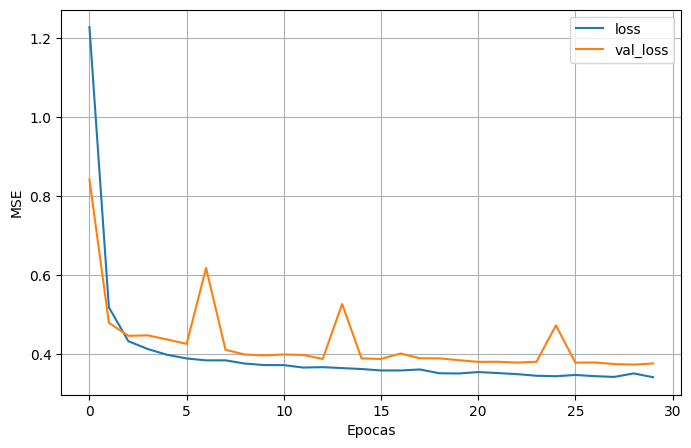

In [ ]:
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.xlabel("Epocas")
plt.ylabel("MSE")
#plt.gca().set_ylim(0,1) # ajusta o eixo y para os limites de 0 a 1
plt.show()

Estimando o valor de algumas amostras não apresentadas durante o treinamento

194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


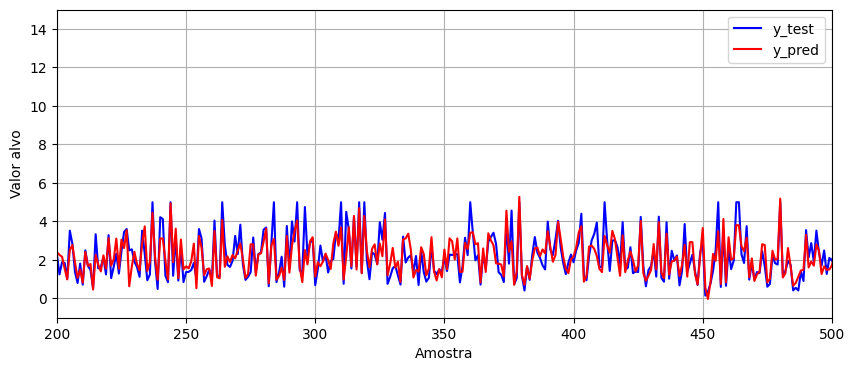

194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3720
O MSE do modelo foi 37.19607%.


In [ ]:
y_pred = model.predict(X_test)

plt.figure(figsize=(10, 4))
plt.grid(True)
plt.plot(range(0,len(y_test)),y_test, "b", label="y_test")
plt.plot(range(0,len(y_pred)),y_pred, "r", label="y_pred")
plt.axis([200, 500, -1, 15])
plt.xlabel("Amostra")
plt.ylabel("Valor alvo")
plt.legend()

plt.show()
mse_test = model.evaluate(X_test,y_test)
print(f"O MSE do modelo foi {mse_test*100:.5f}%.")

##### Busca dos melhores parâmetros para uma rede PMC

A quantidade de parâmetros para ser ajustado é a vantagem e a desvantagem das redes neurais. Por um lado, temos muitos parâmetros para ajustar o modelo da melhor forma aos dados. Por outro lado, existem muitas possibilidades para ajustar o modelo. Podemos fazer uma busca dos melhores parâmetros por meio do algoritmo de treinamento, sem precisar ajustar tudo manualmente.

> **Quantos neurônios devo utilizar?**
>
> Métodos para escolher a quantidade de neurônios na camada escondida.
- Método de Fletcher-Gloss: 2*sqrt(n) +n2 <= n1 <= 2*n+1
- Método de Kolmogorov: n1= 2*n+1
>
> Lembrar que é apenas um chute inicial.

Criando a função do modelo de regressor que será ajustado de forma automática.

In [ ]:
# Criando uma funcao para representar o modelo que sera treinado

# Adicione **kwargs no final para evitar erros de argumentos inesperados
def build_model_reg(model__n_hidden=1, model__n_neurons=30, model__learning_rate=3e-3, model__optimizer="adam", **kwargs):
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=X_train.shape[1:]))

    for _ in range(model__n_hidden):
        model.add(keras.layers.Dense(model__n_neurons, activation="relu"))

    model.add(keras.layers.Dense(1))

    if model__optimizer == "adam":
        opt = keras.optimizers.Adam(learning_rate=model__learning_rate)
    else:
        opt = keras.optimizers.SGD(learning_rate=model__learning_rate)

    model.compile(loss="mse", optimizer=opt)
    return model

Definindo os parâmetros que serão variados:

In [ ]:
# Parametros simplificados
param_distribs = {
    "n_hidden": [1],
    "n_neurons": range(10,30,1),
    "learning_rate": [1e-3]
}

keras_reg = KerasRegressor(build_model_reg, n_hidden=param_distribs["n_hidden"],
                           n_neurons=param_distribs["n_neurons"],
                           learning_rate=param_distribs["learning_rate"],
                           verbose=1)

In [ ]:
rnd_search_cv = RandomizedSearchCV(keras_reg,  param_distribs, n_iter=5, cv=3)

rnd_search_cv.fit(X_train, y_train, epochs=50,
              validation_data=(X_valid,y_valid),
              callbacks=[keras.callbacks.EarlyStopping(patience=10)] # parada precipitada para evitar overfitting. patience=10 deixa ate 10 epocas sem melhora no indicador de desempenho ('val_loss')
              )

Epoch 1/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9530 - val_loss: 0.6060
Epoch 2/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4404 - val_loss: 0.4794
Epoch 3/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4084 - val_loss: 0.4221
Epoch 4/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3817 - val_loss: 0.3975
Epoch 5/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3703 - val_loss: 0.3839
Epoch 6/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3609 - val_loss: 0.4240
Epoch 7/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3529 - val_loss: 0.3824
Epoch 8/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3524 - val_loss: 0.3808
Epoch 9/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3476 - val_loss: 0.3898
Epoch 10/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3499 - val_loss: 0.3978
Epoch 11/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3387 - val_loss: 0.3633
Epoch 12/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

RandomizedSearchCV(cv=3,
                   estimator=KerasRegressor(learning_rate=[0.001], model=<function build_model_reg at 0x7ff13df9bba0>, n_hidden=[1], n_neurons=range(10, 30)),
                   n_iter=5,
                   param_distributions={'learning_rate': [0.001],
                                        'n_hidden': [1],
                                        'n_neurons': range(10, 30)})

In [ ]:
mse_test = rnd_search_cv.best_estimator_.score(X_test,y_test)
print(f"O MSE do modelo foi {mse_test*100:.5f}%.")

194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step
O MSE do modelo foi 76.38966%.


In [ ]:
X_new = X_test[:10]
y_pred = rnd_search_cv.predict(X_new)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([[2.5492709],
       [3.616975 ],
       [2.6025712],
       [1.3056386],
       [2.0615344],
       [1.6328468],
       [3.6309044],
       [1.0442486],
       [1.8843511],
       [1.5378911]], dtype=float32)

Agora já temos um objeto para ser treinado toda vez que for chamado. Precisamos definir quais hiperparâmetros serão alterados para encontrar a melhor configuração de rede PMC. Este processo pode levar algum tempo, não se preocupe (talvez horas).

In [ ]:
import numpy as np
from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV # implementa a k-fold cross-validation

param_distribs = {
    "model__n_hidden": [1, 2],
    # Converte os inteiros do NumPy para int nativo do Python:
    "model__n_neurons": list(range(20, 50)),
    "model__optimizer": ["adam", "sgd"],
    "model__learning_rate": reciprocal(3e-4, 3e-2),
}

rnd_search_cv2 = RandomizedSearchCV(keras_reg, param_distribs, n_iter=10, cv=3, verbose=0)
rnd_search_cv2.fit(X_train, y_train, epochs=100,
                  validation_data=(X_valid,y_valid),
                  callbacks=[keras.callbacks.EarlyStopping(patience=10)])

Streaming output truncated to the last 5000 lines.
Epoch 13/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3551 - val_loss: 0.4004
Epoch 14/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3521 - val_loss: 0.4692
Epoch 15/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3539 - val_loss: 0.5825
Epoch 16/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3570 - val_loss: 0.4349
Epoch 17/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3459 - val_loss: 0.3834
Epoch 18/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3425 - val_loss: 0.3345
Epoch 19/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3314 - val_loss: 0.3401
Epoch 20/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3299 - val_loss: 0.3329
Epoch 21/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3303 - val_loss: 0.3396
Epoch 22/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3265 - val_loss: 0.3327
Epoch 23/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3313 

RandomizedSearchCV(cv=3,
                   estimator=KerasRegressor(learning_rate=[0.001], model=<function build_model_reg at 0x7fbf2c9bd300>, n_hidden=[1], n_neurons=range(10, 30)),
                   param_distributions={'model__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7fbf2c6d78c0>,
                                        'model__n_hidden': [1, 2],
                                        'model__n_neurons': [20, 21, 22, 23, 24,
                                                             25, 26, 27, 28, 29,
                                                             30, 31, 32, 33, 34,
                                                             35, 36, 37, 38, 39,
                                                             40, 41, 42, 43, 44,
                                                             45, 46, 47, 48,
                                                             49],
                                        'model__optimizer': ['adam', 'sgd']})

Ao finalizar o treinamento, podemos acessar os melhores hiperparâmetros de acordo com a função de desempenho. Todos os parâmetros utilizados durante os n_inter treinamentos são relacionados pelo atributo $ cv_results_ $.

In [26]:
rnd_search_cv2.cv_results_

{'mean_fit_time': array([50.20920062, 50.25185951, 52.4737498 , 55.29138001, 57.03489463,
        58.72544599, 60.97847652, 66.66926606, 73.37387172, 67.43342392]),
 'std_fit_time': array([1.16269982, 1.25186429, 0.75919555, 2.98924955, 0.75924056,
        1.47080976, 1.17565253, 3.65529375, 3.32390048, 1.25997704]),
 'mean_score_time': array([0.23359553, 0.27428786, 0.31805476, 0.26560569, 0.25863544,
        0.26501584, 0.36585935, 0.34635592, 0.34909463, 0.34233149]),
 'std_score_time': array([0.00905237, 0.06088009, 0.04780167, 0.00741666, 0.0165782 ,
        0.00940469, 0.03867647, 0.04491255, 0.05053718, 0.03356054]),
 'param_model__learning_rate': masked_array(data=[0.0018413953834643115, 0.0006322581140292455,
                    0.001605967407576298, 0.002951403152643134,
                    0.002073784057398593, 0.0005283896152012034,
                    0.0108970726081338, 0.00208005818610671,
                    0.002456103181769273, 0.000620072875449618],
              mas

Os melhores parâmetros são armazenados nos atributos $ best_params_ $ e $best_score_$.

In [28]:
rnd_search_cv2.best_params_

{'model__learning_rate': np.float64(0.002456103181769273),
 'model__n_hidden': 2,
 'model__n_neurons': 24,
 'model__optimizer': 'sgd'}

In [29]:
rnd_search_cv2.best_score_

np.float64(0.765811964336923)

194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step


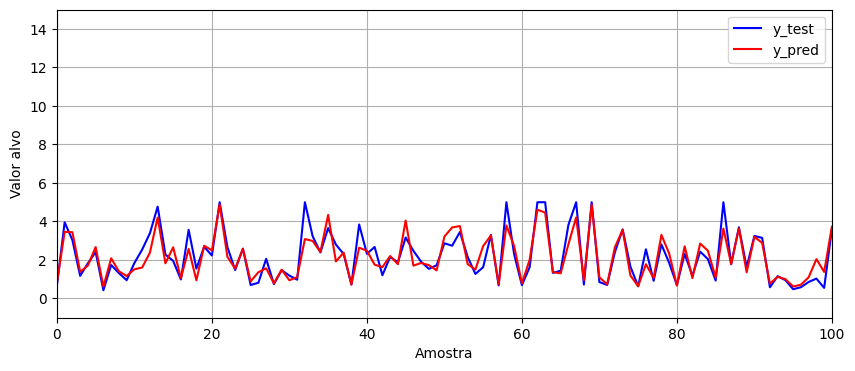

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

y_pred = rnd_search_cv2.best_estimator_.predict(X_test)

plt.figure(figsize=(10, 4))
plt.grid(True)
plt.plot(range(0,len(y_test)),y_test, "b", label="y_test")
plt.plot(range(0,len(y_pred)),y_pred, "r", label="y_pred")
plt.axis([0, 100, -1, 15])
plt.xlabel("Amostra")
plt.ylabel("Valor alvo")
plt.legend()

plt.show()

#### Conhecendo a estrutura, salvando e importando o modelo

##### Estrutura do modelo

É possível conhecer a estrutura do modelo utilizando o `plot_model` do Keras.

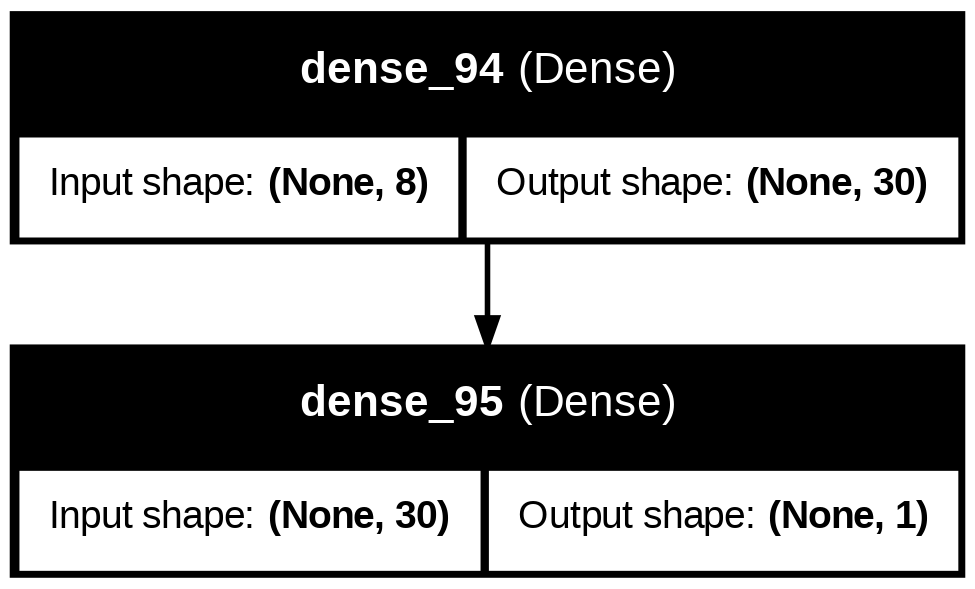

In [31]:
model = rnd_search_cv2.best_estimator_.model_

from keras.utils import plot_model
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

Podemos utilizar a biblioteca Pickle para salvar (serializar) um modelo treinado.

In [32]:
import pickle

with open('modelo_salvo.pickle', 'wb') as f:
    # 'modelo_salvo.pickle' é o nome do arquivo que sera criado
    # o parâmetro 'wb' é para w: write; e b: binário

    # vamos salvar o modelo 'model' dentro do arquivo 'modelo_salvo.pickle'
    pickle.dump(model, f)

O modelo pode ser carregado novamente em outra aplicação por meio do próprio Pickle.

**Cuidado: quando você receber um arquivo de uma fonte não confiável, não carregue. É possível infectar o arquivo com alguma informação nociva.**

In [33]:
with open('modelo_salvo.pickle', 'rb') as f:
    # 'modelo_salvo.pickle' é o nome do arquivo que sera lido
    # o parâmetro 'rb' é para r: read; e b: binário

    # vamos salvar o modelo 'model' dentro do arquivo 'modelo_salvo.pickle'
    modelo_carregado = pickle.load(f)

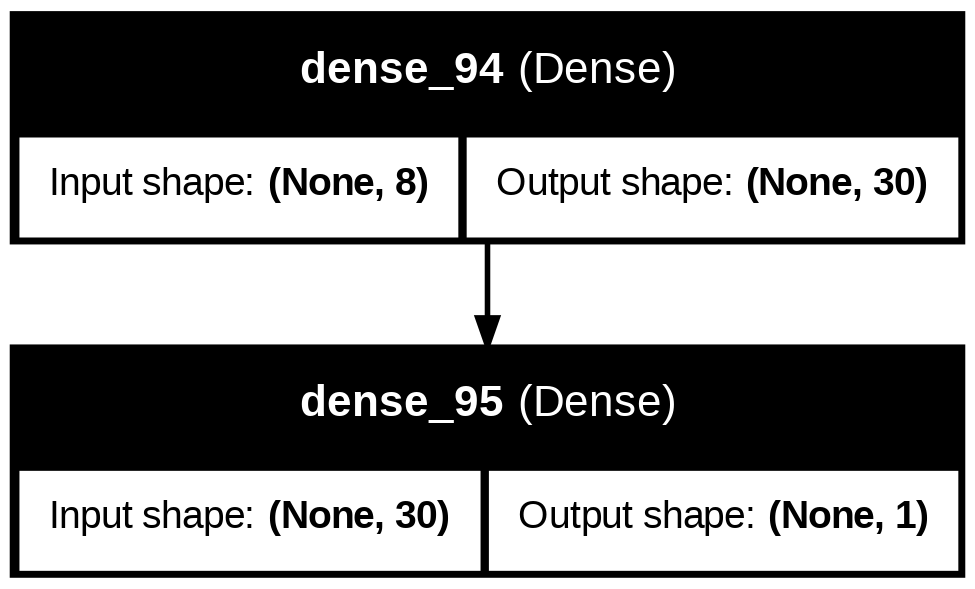

In [34]:
from keras.utils import plot_model
plot_model(modelo_carregado, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

___
___
___

#### Função ajustar os hiperparâmetros do problema de classificação multiclasse

In [39]:
# funcao para criar o modelo

def build_model_clf(
    n_hidden=1,
    n_neurons=30,
    learning_rate=3e-3,
    activation="relu",
    input_shape=[28, 28]
):

    model = keras.models.Sequential()

    model.add(keras.layers.Flatten(input_shape=input_shape))

    for _ in range(n_hidden):
        model.add(
            keras.layers.Dense(
                n_neurons,
                activation=activation
            )
        )

    model.add(keras.layers.Dense(10, activation="softmax"))

    optimizer = keras.optimizers.SGD(
        learning_rate=learning_rate
    )

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=optimizer,
        metrics=["accuracy"]
    )

    return model

In [40]:
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier
from scipy.stats import reciprocal
import numpy as np

# Hiperparâmetros que serão testados
param_distribs = {
    "model__n_hidden": [1, 2],
    "model__n_neurons": np.arange(20, 50),
    "model__learning_rate": reciprocal(3e-4, 3e-2),
    "model__activation": ["relu", "sigmoid", "tanh"],
}

# Instanciando o modelo
model = KerasClassifier(
    model=build_model_clf,
    epochs=10,
    batch_size=32,
    verbose=0
)

# Busca aleatória dos hiperparâmetros
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distribs,
    n_iter=10,
    cv=3,
    random_state=42
)

In [ ]:
# Exemplo de uso para um problema de classificação multiclasse

# random_search_result = random_search.fit(
#     X_train_classificacao,
#     y_train_classificacao
# )

# print(random_search_result.best_params_)
# print(random_search_result.best_score_)